# Package

In [135]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize)
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

# Importation

In [122]:
carseats = load_data("carseats")

In [123]:
carseats.shape

(400, 11)

In [124]:
carseats.head(2)

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes


*Les variables*
- Sales : Unit sales (in thousands) at each location

- CompPrice : Price charged by competitor at each location

- Income : Community income level (in thousands of dollars)

- Advertising : Local advertising budget for company at each location (in thousands of dollars)

- Population : Population size in region (in thousands)

- Price : Price company charges for car seats at each site

- ShelveLoc : A factor with levels Bad, Good and Medium indicating the quality of the shelving location for the car seats at each site

- Age : Average age of the local population

- Education : Education level at each location

- Urban : A factor with levels No and Yes to indicate whether the store is in an urban or rural location

- US : A factor with levels No and Yes to indicate whether the store is in the US or not

# Feature engineering

In [ ]:
# Changement de type
carseats.Urban = carseats.Urban.map({"Yes" : 1, "No" : 0})
carseats.US = carseats.US.map({"Yes" : 1, "No" : 0})

# La prochaine fois, à chaque calcul sur une colonne on utilise lambda

# a) Fit Multiple regression model to predict Sales using Price, Urban, and US

## a1) Define the features and target

In [126]:
cols = list(carseats.columns)
print(cols.index("Sales"), cols.index("Price"), cols.index("Urban"), cols.index("US") )

0 5 9 10


In [127]:
X_cols = [cols[5], cols[9], cols[10]]
X = MS(X_cols).fit_transform(carseats)
Y = carseats["Sales"]

In [128]:
model_1 = sm.OLS(Y, X)
result_1 = model_1.fit()
print(result_1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     41.52
Date:                Mon, 29 Dec 2025   Prob (F-statistic):           2.39e-23
Time:                        15:23:19   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1863.
Df Residuals:                     396   BIC:                             1879.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     13.0435      0.651     20.036      0.0

# b) Interpretation 

**Significativité globale**

Vu le p-value du test de Fisher < 0.01, le modèle est donc significatif d'une manière globale

**Significativité de chaque variable**

Seule la variable "Urban" qui n'est donc pas significative.

**Price**

Le coefficient de "Price" sur "Sales" est négatif : -0.05. Ainsi, une augmentation 1$ du prix de l'automobile fait diminuer de 50 unités de sièges pour enfant vendus.

**US**

Le coefficient de "USA" sur "Sales" est égal à 1.2006. Le fait que le magasin soit aux Etats-Unis entraine une augmentation de 1000 unités. 

c) Model equation

Sales = -0.0545 * Price + 1.2006 * USA - 0.0219 * URBAN

# d) Significativité

Déjà répondu

# e) Linear Regression with significant variables

In [129]:
X_cols.remove("Urban")

In [130]:
X = MS(X_cols).fit_transform(carseats)

In [131]:
model_2 = sm.OLS(Y, X)
result_2 = model_2.fit()
print(result_2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     62.43
Date:                Mon, 29 Dec 2025   Prob (F-statistic):           2.66e-24
Time:                        15:23:19   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1861.
Df Residuals:                     397   BIC:                             1873.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     13.0308      0.631     20.652      0.0

# f) Howe well do the models in (a) and (e) fit the model?

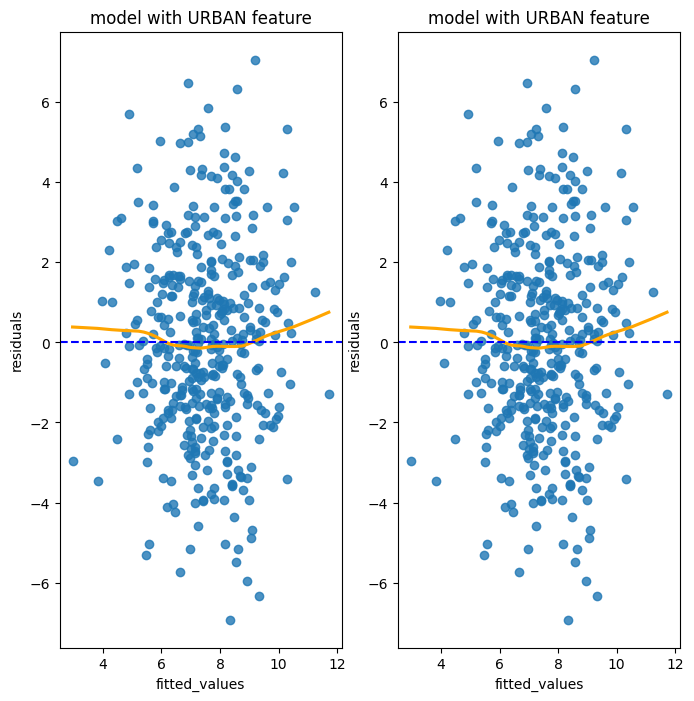

In [153]:
fig, axs = plt.subplots(1,2, figsize = (8,8))

sns.regplot(
    x = result_1.fittedvalues,
    y = result_1.resid,
    lowess=True,
    line_kws={"color" :"orange"},
    ax = axs[0]
)

axs[0].axhline(color = "b", linestyle = "--")
axs[0].set_xlabel("fitted_values")
axs[0].set_ylabel("residuals")
axs[0].set_title("model with URBAN feature")

sns.regplot(
    x = result_1.fittedvalues,
    y = result_1.resid,
    lowess=True,
    line_kws={"color" :"orange"},
    ax = axs[1]
)
axs[1].axhline(color = "b", linestyle = "--")
axs[1].set_xlabel("fitted_values")
axs[1].set_ylabel("residuals")
axs[1].set_title("model with URBAN feature")

plt.show()

En termes de fit, les deux modèles sont les mêmes. Ils se rapprochent de la linéarité des données.

# g) Confidence intervals for the coefficient

In [162]:
result_2.conf_int(alpha=0.05)

,0,1
intercept,11.79032,14.271265
Price,-0.06476,-0.044195
US,0.69152,1.707766


# h) Outliers

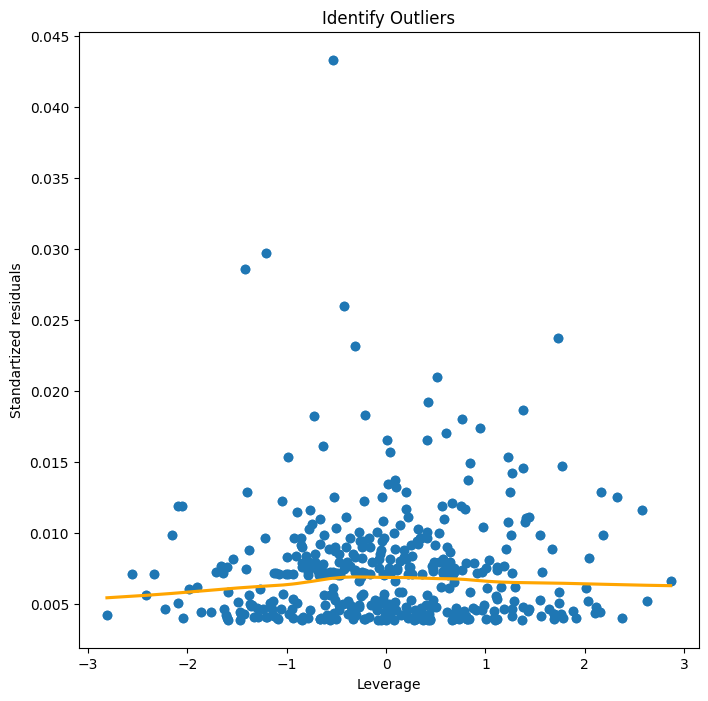

In [179]:
infl = result_2.get_influence()
r = infl.resid_studentized_internal
h = infl.hat_matrix_diag

fig, ax = plt.subplots(figsize = (8,8))
ax.scatter(r,h)

sns.regplot(
    x = r,
    y = h,
    lowess=True,
    ci=False,
    line_kws={"color" : "orange"}
)

ax.set_title("Identify Outliers")
ax.set_xlabel("Leverage")
ax.set_ylabel("Standartized residuals")
plt.show()

Leverage : c'est la contribution d'un point sur la prédiction y

Std_residual : l'écart entre la prédiction et la vraie valeur normalisé

Voici la règle d'intérprétation : 
- L élevé et SR faible : Combinaison de X très atypique (Outlier), çà dépend des données ; 
- L élevé et SR fort : influent ; 
- L faible et SR faible : point normal ; 
- L faible et SR élevé : Le modèle explique mal ce point. çà dépend de la spécification du modèle.

Nous avons donc un point qui a un L faible et SR très élevé. Nous pourrons encore améliorer ce modèle en ajoutant d'autres variables explicatives.